# Laboratorium 4 — gra Izolacja, agent MCTS

**Cel:** zaimplementować Monte Carlo Tree Search dla gry dwuosobowej i zmierzyć skuteczność agenta MCTS (czerwony) przeciwko graczowi losowemu (niebieski) na planszy 7×5.


## Zasady gry (skrót)

- Dwóch graczy, czerwony zaczyna; każdy ma jeden pionek.
- Pierwszy ruch: dowolne wolne pole; dalej ruchy jak hetman, bez skakania przez przeszkody; opuszczone pole staje się na stałe zablokowane (`#`).
- Brak legalnego ruchu oznacza przegraną bieżącego gracza.


## Realizacja: UCB i wybór ruchu

W szkielecie funkcja `select` zwracała `None`, a wartości dzieci nie były oceniane. Dodałem wzór UCB: dla dziecka z zerową liczbą wizyt zwracam nieskończoność, żeby najpierw odwiedzić każde dziecko. Eksploatacja opiera się na `child.value` (interpretacja w komentarzu): gracz w rodzicu maksymalizuje `1 - child.value`. Przy `final=True` wybieram ruch o największej liczbie symulacji (remisy losowo).

```python
    def ucb_score(self, child: "MCTSNode") -> float:
        n = child.times_chosen
        if n == 0:
            return float("inf")  # niewypróbowane — najpierw je

        # child.value = P(gracz przy ruchu w dziecku wygrywa) = P(przeciwnik rodzica wygrywa);
        # rodzic maksymalizuje własną szansę: eksploatacja = 1 - child.value
        Q = 1.0 - child.value
        N = self.times_chosen
        exploration = self.c_coefficient * math.sqrt(math.log(max(1, N)) / n)
        return Q + exploration

    def select(self, final=False) -> tuple[int, int]:
        if final:
            if not self.children:
                raise RuntimeError("select(final=True): brak dzieci — rozważ reset MCTS lub expand przed wyborem")
            max_visits = max(self.children[move].times_chosen for move in self.children)
            candidates = [move for move in self.children if self.children[move].times_chosen == max_visits]
            return random.choice(candidates)

        best_score = float("-inf")
        candidates: list[tuple[int, int]] = []
        for move, child in self.children.items():
            score = self.ucb_score(child)
            if score > best_score:
                best_score = score
                candidates = [move]
            elif score == best_score:
                candidates.append(move)
        return random.choice(candidates)
```


## Rozwinięcie liścia, symulacja, propagacja wstecz

`expand` tworzy dzieci dla wszystkich legalnych ruchów. `simulate` to losowy rollout do końca partii. `backpropagate` idzie po `parent` i aktualizuje średnią wygraną bieżącego gracza oraz licznik wizyt.

```python
    def simulate(self) -> Colour:
        if self.terminal:
            return self.current_player.flip()
        else:
            starting_board = self.board.duplicate()
            current_player = self.current_player

            while True:
                legal_moves = starting_board.moves_for(current_player)
                if len(legal_moves) == 0:
                    return current_player.flip()

                move = random.choice(legal_moves)
                starting_board.apply_move(current_player, move)
                current_player = current_player.flip()

            return None

    def backpropagate(self, winner: Colour) -> None:
        current_node = self
        while current_node is not None:
            old_N = current_node.times_chosen
            new_N = old_N + 1
            old_Q_avg = current_node.value
            old_Q_sum = old_Q_avg * old_N
            new_Q_sum = old_Q_sum + (1 if winner == current_node.current_player else 0)
            new_Q_avg = new_Q_sum / new_N
            current_node.value = new_Q_avg
            current_node.times_chosen = new_N
            current_node = current_node.parent
```


## Klasa `MCTSPlayer`

Jeśli korzeń drzewa nie pasuje do aktualnego stanu planszy (np. pierwszy ruch lub desynchronizacja), buduję nowy `MCTSNode`. Po wyczerpaniu limitu czasu wybieram ruch `select(final=True)` i schodzę w dół drzewa.

```python
    def choose_action(self, board: Board, current_player: Colour) -> tuple[int, int]:
        stale = (
            self.root_node is None
            or self.root_node.board.to_state_str() != board.to_state_str()
            or self.root_node.current_player != current_player
        )
        if stale:
            self.root_node = MCTSNode(board.duplicate(), current_player, self.c_coefficient)

        start_time = time.time()
        while True:
            self._mcts_iteration()
            if time.time() - start_time >= self.time_limit:
                break

        action = self.root_node.select(final=True)
        self._step_down(action)
        return action
```


### Mała modyfikacja

Dodałem też `copy()` do powielania agenta przy serii gier oraz opcjonalne czyszczenie drzewa. Było to konieczne ponieważ kiedy przekazywałem klasę gracza jako parametr do funkcji, efektywnie gracz zaczynał kolejną rundę (ze 100) z już rozpoczętym przez pierwszego agenta drzewem. Referencja jak parametr funkcji wciąć podtrzymywała obiekt przy życiu, co uniemożliwiało jego resetowanie

```python
class MCTSPlayer(Player):
    def __init__(self, time_limit: float, c_coefficient: float):
        self.time_limit: float = time_limit
        self.root_node: Optional[MCTSNode] = None
        self.c_coefficient: float = c_coefficient

    def clear_tree(self) -> None:
        """Odrzuć drzewo MCTS (np. przed nową partią). Następny ruch zbuduje korzeń od zera."""
        self.root_node = None

    def copy(self) -> "MCTSPlayer":
        """Nowy agent z tymi samymi parametrami (time_limit, c_coefficient), bez drzewa."""
        return MCTSPlayer(self.time_limit, self.c_coefficient)

    def __del__(self) -> None:
        # Nie polegaj na tym między kolejnymi partiami — ten sam Player żyje przez wiele gier.
        # Przy usuwaniu obiektu puść referencję do dużego drzewa, żeby GC mógł je zebrać.
        self.root_node = None

    def choose_action(self, board: Board, current_player: Colour) -> tuple[int, int]:
        stale = (
            self.root_node is None
            or self.root_node.board.to_state_str() != board.to_state_str()
            or self.root_node.current_player != current_player
        )

    # ...
    for _ in range(n_games):
        board = Board(7, 5)
        red_player = player.copy()
        blue_player = RandomPlayer()
    # ...
```


Zdecydowałe się na takie podejście ponieważ ułatwiało to rozpatrzenie wszystkich kombinacji sprawdzanych parametrów

```python

    c_coefficients = [
                        1.0,
                        0.9,
                        0.8,
                        0.75,
                        0.7,
                        0.6,
                        0.5,
                        0.4,
                        0.3,
                        0.25,
                        0.2,
                        0.1,
                        0.0,
                    ]

    time_limits = [ 
                    0.2,           # 200   ms
                    0.1,           # 100   ms
                    0.05,          # 50    ms
                    0.025,         # 25    ms
                    0.01,          # 10    ms

                    0.005,         # 5     ms
                    0.004,         # 4     ms
                    0.003,         # 3     ms
                    0.0025,        # 2.5   ms
                    0.002,         # 2     ms
                    0.0015,        # 1.5   ms
                    0.001,         # 1     ms
                    0.0005,        # 0.5   ms

                    0.00025,       # 0.25  ms
                    0.0001,        # 0.1   ms
                    0.00005,       # 0.05  ms
                    0.000025,      # 0.025 ms
                    0.00001,       # 0.01  ms
                    0.000005,      # 0.005 ms
                    0.0000025,     # 0.0025 ms

                    0.000001,      # 0.001  ms
                    0.0000005,     # 0.0005 ms
                ]
```

Stworzenie obiektów Player z takimi parametrami oraz uruchomienie algorytmu dla wszystkich wariantów


## Eksperyment: pomiar i przyspieszenie

Funkcja `main` zwraca liczbę wygranych czerwonego w `n_games` partiach. Dla `MCTSPlayer` domyślnie uruchamiam partie równolegle w procesach (`ProcessPoolExecutor`), żeby skrócić czas obliczeń (GIL ogranicza wątki przy CPU-bound MCTS). Każda para parametrów `(time_limit, c)` jest powtarzana `num_outer_runs` razy (w kodzie 5), w każdym runie 100 gier; wyniki zapisuję do CSV i generuję wykresy w katalogu `plots/`.

```python
def _play_mcts_vs_random_once(job: tuple[float, float, int]) -> int:
    time_limit, c_coefficient, seed = job
    random.seed(seed)
    board = Board(7, 5)
    red_player = MCTSPlayer(time_limit, c_coefficient)
    blue_player = RandomPlayer()
    game = Game(red_player, blue_player, board)
    game.run(verbose=False)
    return 1 if game.winner == Colour.RED else 0

def main(
    player: Player,
    *,
    n_games: int = 100,
    parallel_games: bool = True,
    max_workers: Optional[int] = None,
) -> int:
    if parallel_games and isinstance(player, MCTSPlayer):
        workers = max_workers if max_workers is not None else (os.cpu_count() or 1)
        if workers > 1:
            t, c = player.time_limit, player.c_coefficient
            jobs = [(t, c, i) for i in range(n_games)]
            red_wins = 0
            with ProcessPoolExecutor(max_workers=workers) as ex:
                for result in ex.map(_play_mcts_vs_random_once, jobs):
                    red_wins += result
            print(f"{red_wins} - {n_games - red_wins}", end="", flush=True)
            return red_wins
```


## Wyniki

Poniżej wykresy zapisane przez skrypt: oś X na pierwszym rysunku to limit czasu na ruch (skala logarytmiczna, sekundy), na drugim — współczynnik `c`; oś Y — średnia liczby wygranych czerwonego w 100 grach, uśredniona z **5** niezależnych runów dla każdej konfiguracji (`num_outer_runs = 5`).

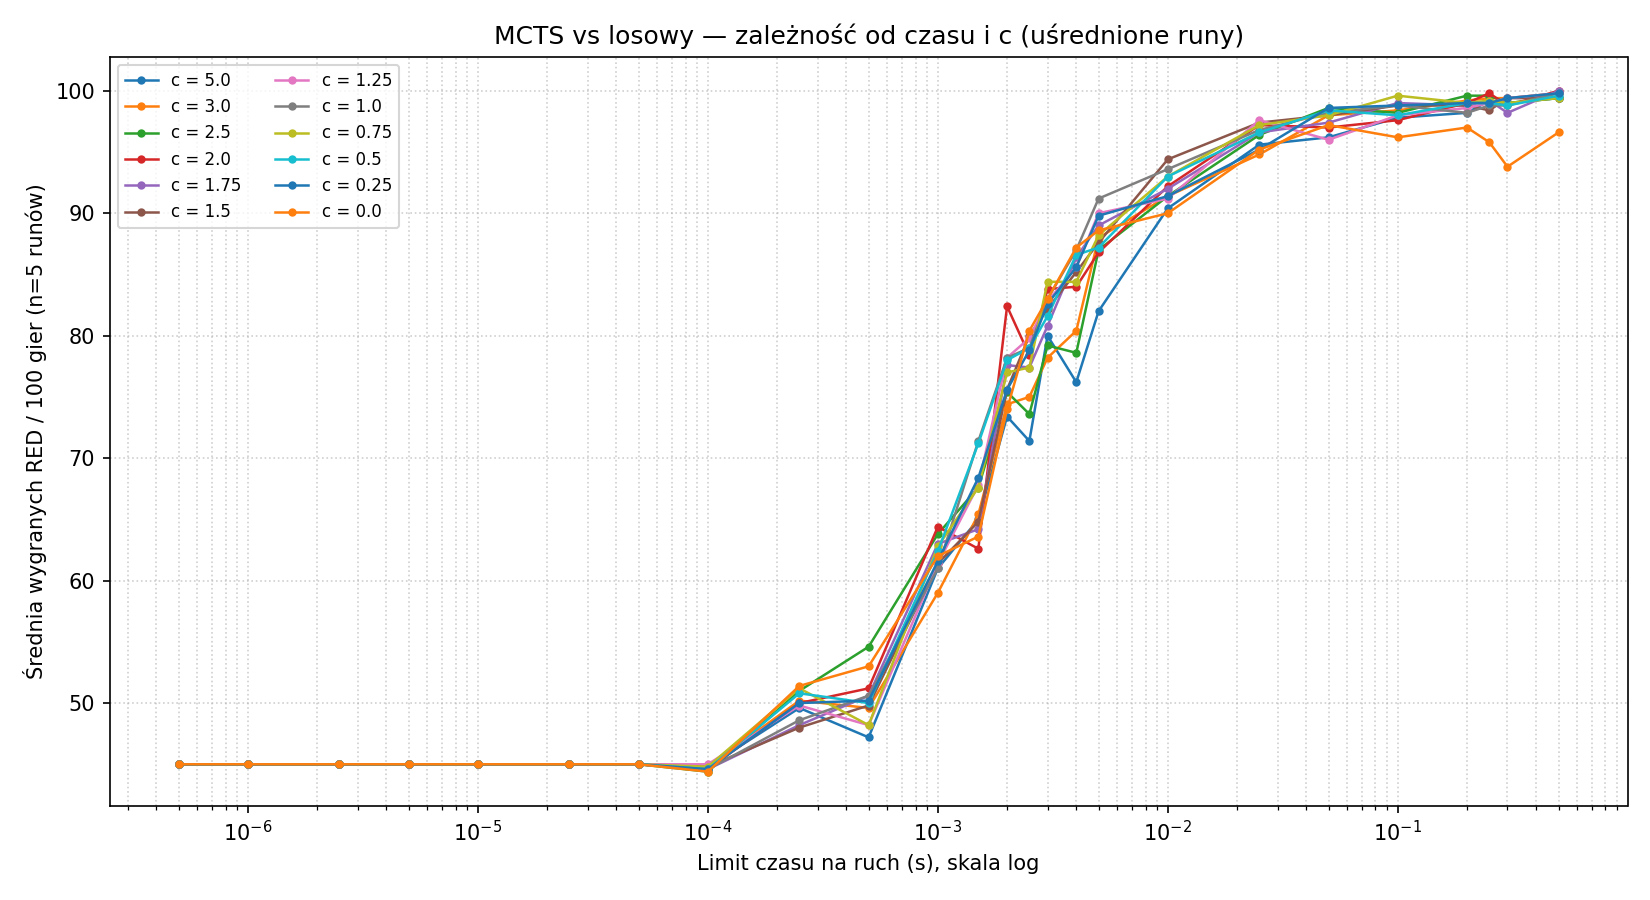

Przy bardzo małym limicie czasu średnia wygrana oscyluje w okolicy 50%, czyli MCTS zdąża wykonać tak mało iteracji, że zachowuje się podobnie do losowego gracza. Od okolic \(10^{-4}\) s w górę krzywe szybko rosną; przy dłuższym czasie (np. od ok. 10 ms) wszystkie wartości `c` dają wysoką skuteczność — krzywe dla różnych `c` leżą blisko siebie, więc w tym eksperymencie **budżet czasu ma większe znaczenie niż dobór `c`**.

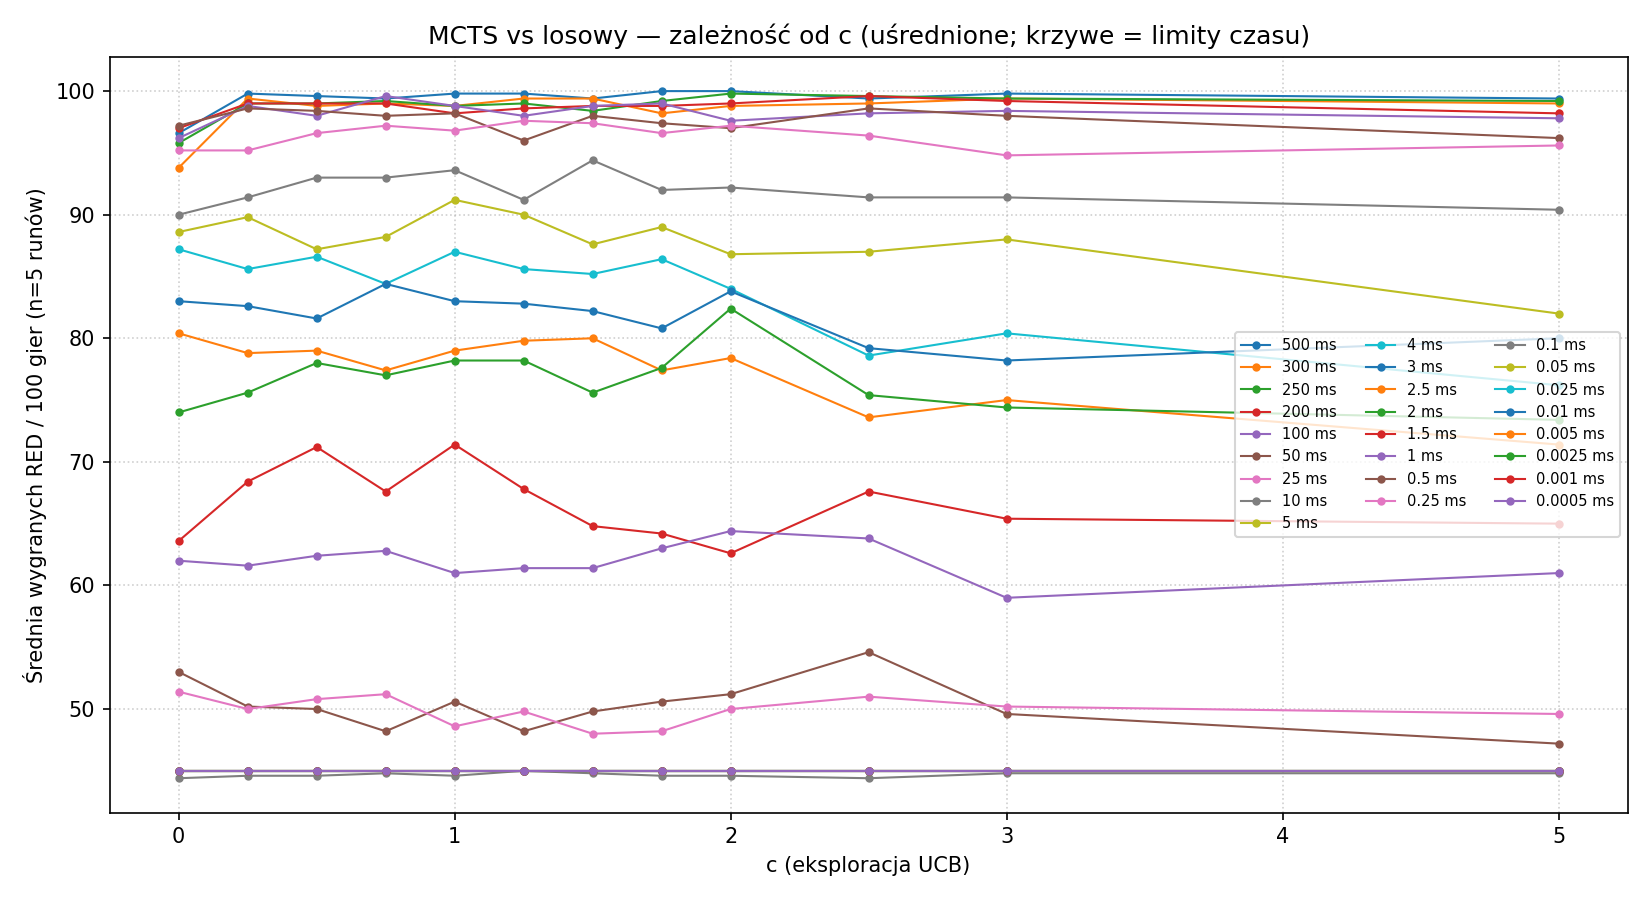

Przy ustalonym limicie czasu widać większą rozpiętość między krzywymi odpowiadającymi różnym `c` w średnim zakresie czasu; przy najdłuższych limitach wszystkie konfiguracje zbliżają się do maksimum. Potwierdza to, że przy wystarczająco głębokim przeszukiwaniu wybór eksploracji w UCB jest drugorzędny względem liczby iteracji MCTS.


## Wnioski

Zaimplementowany MCTS zgodnie z typową pętlą select–expand–simulate–backpropagate pokonuje gracza losowego stabilnie przy odpowiednio długim limicie czasu na ruch. Z pomiarów wynika, że najpierw należy zapewnić wystarczający budżet obliczeń; dopiero przy jego braku parametr `c` widocznie modyfikuje wynik. Równoległe liczenie partii w `main` skraca czas zbierania danych bez zmiany logiki gry.
